In [1]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import seaborn as sns

from afolu.assets.constants import LABEL_LIST
from afolu.assets.emissions import build_dataset, generate_model_objects

/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/munch/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
ZONE = "PER+Coronel Portillo"

In [3]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [115]:
areas = pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
transitions = pd.read_csv(
    out_path / "small" / "transition" / "cube" / f"{ZONE}.csv"
).set_index("time_period")

transition_mat = np.zeros((len(transitions), len(LABEL_LIST), len(LABEL_LIST)))
for idx, row in transitions.iterrows():
    data = (
        row.rename("value")
        .reset_index()
        .assign(
            index=lambda df: df["index"].str.replace("pij_lndu_", ""),
            start=lambda df: df["index"].str.split("_to_").str[0].str.strip(),
            end=lambda df: df["index"].str.split("_to_").str[1].str.strip(),
        )
        .drop(columns=["index"])
        .pivot_table(index="start", columns="end", values="value")
    )
    data = data.sort_index(axis=0)
    data = data.sort_index(axis=1)
    transition_mat[idx, :, :] = data.to_numpy()

In [57]:
df_area = (
    pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
    .set_index("label")
    .T
)
df_area.index = df_area.index.astype(int)

missing_cols = set(LABEL_LIST) - set(df_area.columns)
for col in missing_cols:
    df_area[col] = 0

df_area = df_area[[c for c in sorted(df_area.columns)]]

df_area_frac = df_area.div(df_area.sum(axis=1), axis=0)

In [61]:
def get_area_coefficients(df_area: pd.DataFrame) -> dict[str, np.ndarray]:
    X = df_area.index.to_numpy().reshape(-1, 1)

    coefs = {}
    for label in LABEL_LIST:
        y = df_area[label].to_numpy()
        coef = np.polyfit(X.flatten(), y, 1)
        coefs[label] = coef

    return coefs

In [62]:
abs_coefficients = get_area_coefficients(df_area)
frac_coefficients = get_area_coefficients(df_area_frac)

In [68]:
def plot_fit_grid(df: pd.DataFrame, coefficients: dict[str, np.ndarray]) -> None:
    fig, ax = plt.subplots(4, 3, figsize=(15, 10))

    X = df.index.to_numpy()
    for label, ax in zip(LABEL_LIST, ax.flatten(), strict=False):
        y = df[label].to_numpy()

        coef = coefficients[label]
        yhat = np.polyval(coef, X)

        ax.scatter(X, y)
        ax.plot(X, yhat, color="red")

        ax.set_title(label)
    fig.tight_layout()

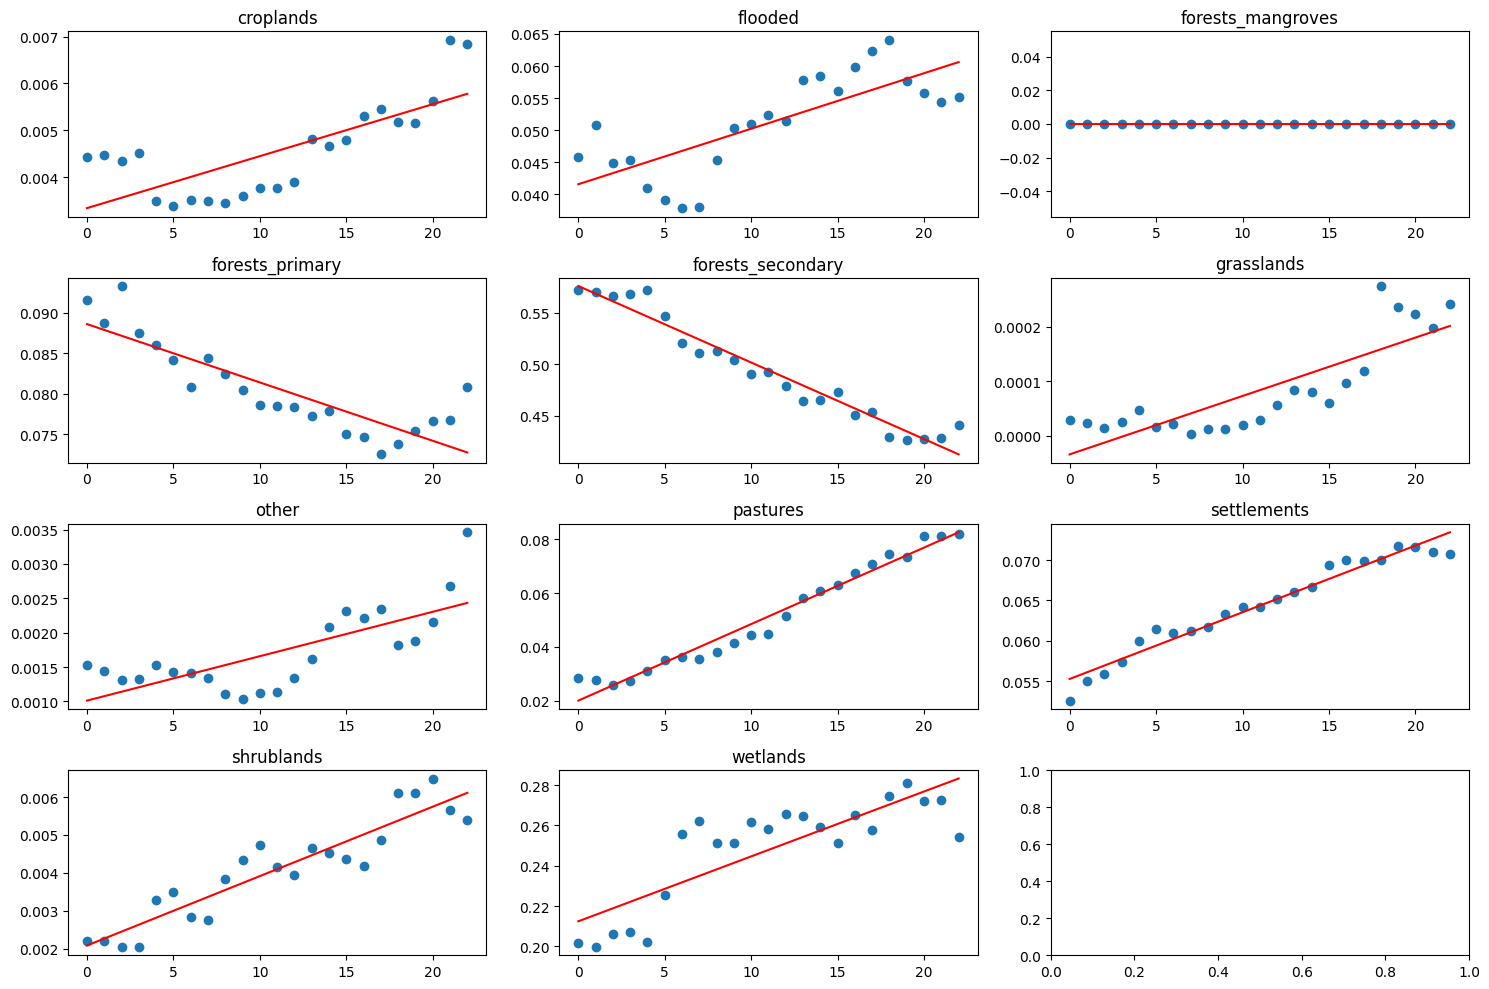

In [70]:
plot_fit_grid(df_area_frac, frac_coefficients)

In [8]:
def derive_coef(x: float, orig_coef: np.ndarray, scale: float) -> np.ndarray:
    new_slope = orig_coef[0] * scale
    new_intersect = np.polyval(orig_coef, x) - new_slope * x
    return np.array([new_slope, new_intersect])


def predict_scaled(x: float, orig_coef: np.ndarray, scale: float) -> float:
    coef = derive_coef(x[0], orig_coef, scale)
    return np.polyval(coef, x)

In [85]:
X = df_area_frac.index.to_numpy()
X_future = np.arange(X[-1] + 1, X[-1] + 11)

coef = frac_coefficients["settlements"]

yhat = np.polyval(coef, X)
y_normal = predict_scaled(X_future, coef, 1.0)
y_fast = predict_scaled(X_future, coef, 1.5)
y_slow = predict_scaled(X_future, coef, 0.5)

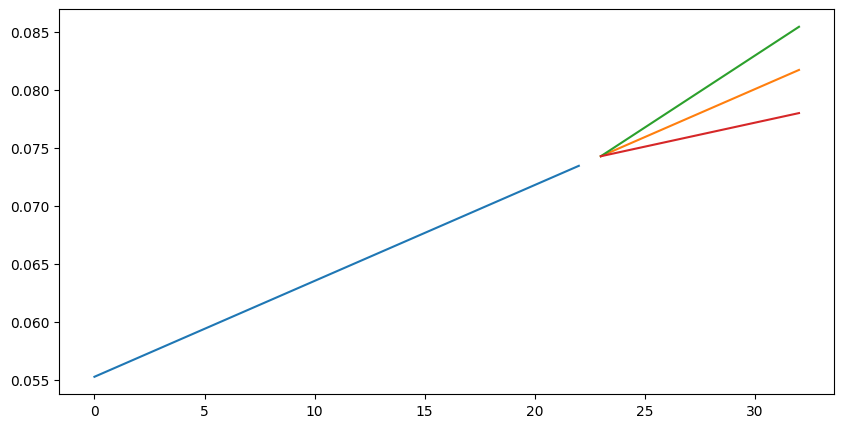

In [87]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(X, yhat)
ax.plot(X_future, y_normal)
ax.plot(X_future, y_fast)
ax.plot(X_future, y_slow)

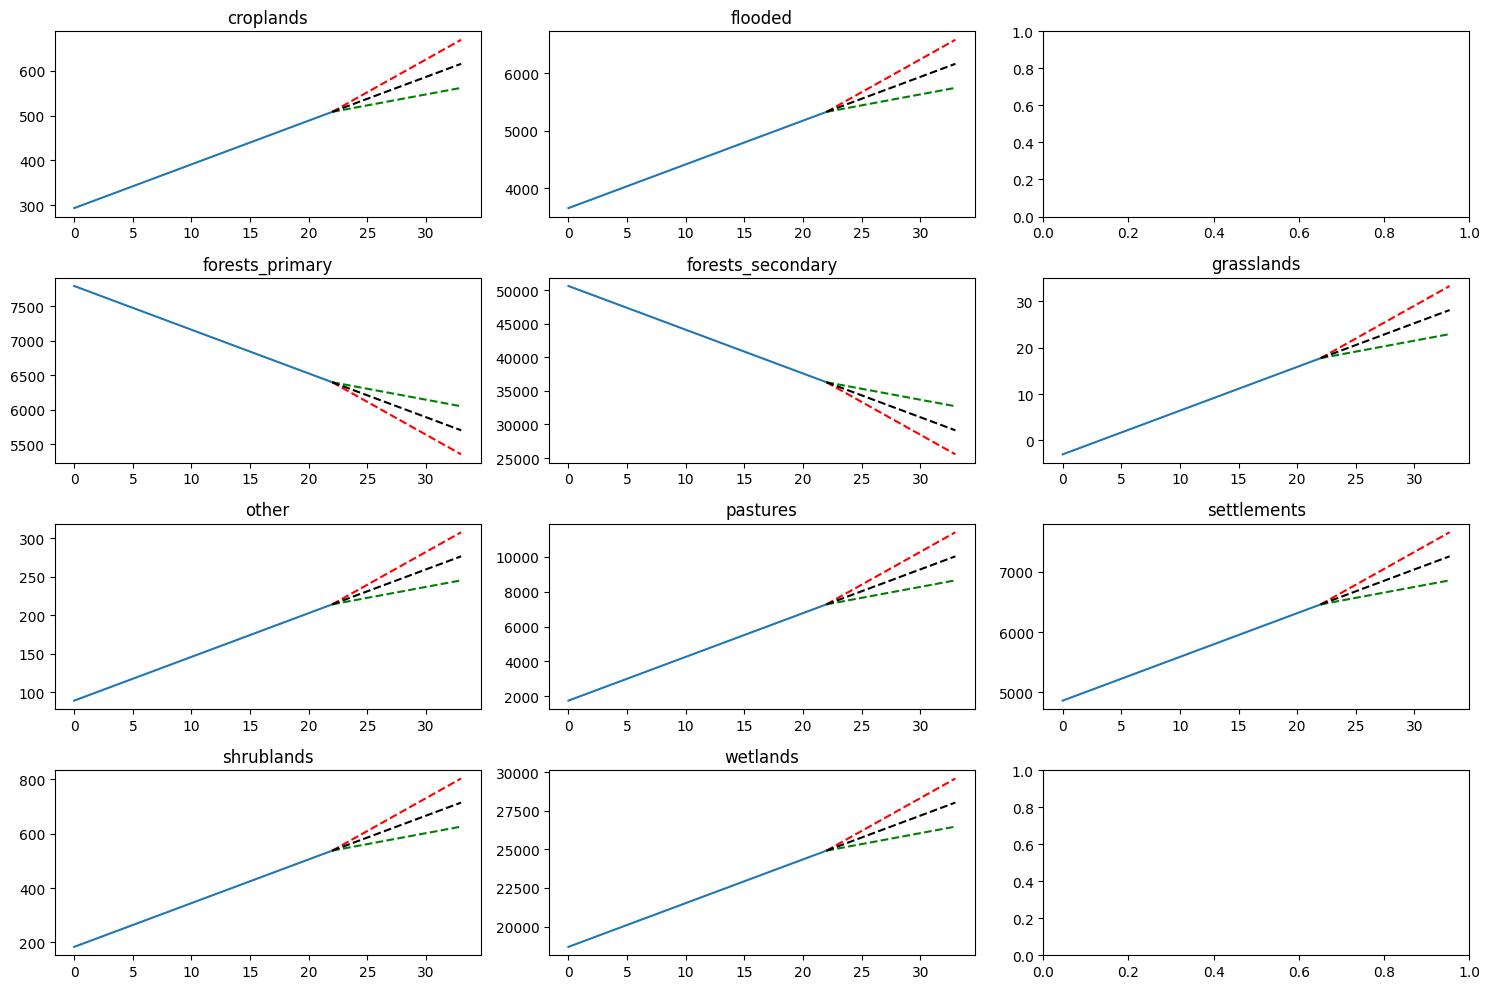

In [9]:
x = X.flatten()
x_future = np.arange(22, 34)

fig, axes = plt.subplots(4, 3, figsize=(15, 10))

for label, ax in zip(LABEL_LIST, axes.flatten(), strict=False):
    if label not in df_area.columns:
        continue

    coef = coefs[label]
    yhat = np.polyval(coef, x)
    pred_fast = predict_scaled(x_future, coef, 1.5)
    pred_slow = predict_scaled(x_future, coef, 0.5)
    pred_normal = predict_scaled(x_future, coef, 1.0)

    ax.plot(x, yhat)
    ax.plot(x_future, pred_fast, linestyle="--", c="red")
    ax.plot(x_future, pred_slow, linestyle="--", c="green")
    ax.plot(x_future, pred_normal, linestyle="--", c="black")
    ax.set_title(label)

fig.tight_layout()

In [161]:
df_area

label,croplands,flooded,forests_mangroves,forests_primary,forests_secondary,grasslands,other,pastures,settlements,shrublands,wetlands
0,389.279580,4022.109122,0,8046.859351,50313.600406,2.565548,134.603133,2504.523994,4624.285240,193.188385,17717.101732
1,393.354952,4466.111612,0,7796.446767,50125.848564,2.066707,126.706490,2445.021074,4833.444020,193.754307,17565.361997
2,382.028828,3950.359859,0,8203.356057,49813.958291,1.238509,114.825582,2276.859709,4913.744903,179.936291,18111.808461
3,396.820205,3988.730749,0,7693.735354,49925.856147,2.295617,116.265592,2403.898397,5047.771720,180.221687,18192.521024
4,307.752256,3598.188789,0,7568.090159,50262.959496,4.246290,134.586373,2733.854436,5271.214773,288.369614,17778.854305
5,296.966113,3442.006293,0,7395.850290,48067.995920,1.415482,124.951050,3081.500900,5406.179782,307.965244,19823.285416
6,309.857636,3327.560265,0,7111.586102,45801.448952,1.946301,124.048750,3184.589678,5360.887147,250.274766,22475.916894
7,306.732766,3349.454987,0,7425.574812,44936.904341,0.353880,117.934603,3119.167726,5385.297038,243.106541,23063.589796
8,303.210929,3992.342584,0,7244.954691,45085.857354,1.061585,97.555784,3350.760909,5422.263302,338.118975,22111.990376
9,315.733225,4426.130160,0,7071.118789,44327.763354,1.061632,91.567003,3654.315256,5571.235301,380.489167,22108.702603


In [162]:
transitions

,pij_lndu_croplands_to_croplands,pij_lndu_croplands_to_flooded,pij_lndu_croplands_to_forests_mangroves,pij_lndu_croplands_to_forests_primary,pij_lndu_croplands_to_forests_secondary,pij_lndu_croplands_to_grasslands,pij_lndu_croplands_to_other,pij_lndu_croplands_to_pastures,pij_lndu_croplands_to_settlements,pij_lndu_croplands_to_shrublands,...,pij_lndu_wetlands_to_flooded,pij_lndu_wetlands_to_forests_mangroves,pij_lndu_wetlands_to_forests_primary,pij_lndu_wetlands_to_forests_secondary,pij_lndu_wetlands_to_grasslands,pij_lndu_wetlands_to_other,pij_lndu_wetlands_to_pastures,pij_lndu_wetlands_to_settlements,pij_lndu_wetlands_to_shrublands,pij_lndu_wetlands_to_wetlands
time_period,,,,,,,,,,,,,,,,,,,,,
0,0.972728,0.000000,0.0,0.0,0.022045,0.0,0.000000,0.003636,0.000227,0.000000,...,0.042705,0.0,0.0,0.238846,0.000005,0.002052,0.000404,0.000574,0.000891,0.714497
1,0.920382,0.000000,0.0,0.0,0.074895,0.0,0.000000,0.001799,0.000675,0.000000,...,0.033587,0.0,0.0,0.246409,0.000000,0.002057,0.000141,0.000640,0.000860,0.716260
2,0.925907,0.000000,0.0,0.0,0.065061,0.0,0.000000,0.004631,0.002084,0.000000,...,0.039220,0.0,0.0,0.246537,0.000015,0.002482,0.000586,0.000762,0.000876,0.709468
3,0.692611,0.000000,0.0,0.0,0.290669,0.0,0.000000,0.012261,0.001784,0.000223,...,0.039958,0.0,0.0,0.255409,0.000058,0.002778,0.000895,0.000795,0.003467,0.696606
4,0.872079,0.000287,0.0,0.0,0.120735,0.0,0.000000,0.004025,0.000287,0.000287,...,0.030792,0.0,0.0,0.174759,0.000000,0.001764,0.000309,0.000468,0.001423,0.790435
5,0.943224,0.000000,0.0,0.0,0.045753,0.0,0.000000,0.004468,0.000596,0.000000,...,0.022396,0.0,0.0,0.143008,0.000009,0.002013,0.000165,0.000411,0.000968,0.831017
6,0.912920,0.000000,0.0,0.0,0.079942,0.0,0.000286,0.001713,0.000286,0.000000,...,0.031895,0.0,0.0,0.177081,0.000004,0.001921,0.000386,0.000394,0.000512,0.787753
7,0.895592,0.000289,0.0,0.0,0.083930,0.0,0.000000,0.009518,0.001730,0.001154,...,0.053537,0.0,0.0,0.187861,0.000012,0.001920,0.001612,0.000848,0.001335,0.752802
8,0.914378,0.000000,0.0,0.0,0.069575,0.0,0.000000,0.007878,0.001751,0.000875,...,0.048055,0.0,0.0,0.158617,0.000024,0.001763,0.001468,0.000609,0.001594,0.787810


In [169]:
def emissions_small(
    areas: pd.DataFrame,
    transitions: pd.DataFrame,
    *,
    iso: str,
) -> pd.DataFrame:
    # Initialize SISEPUEDE objects
    examples, _, model_afolu, regions, time_periods = generate_model_objects()

    temp = areas.set_index("label")

    areas_frac = temp.div(temp.sum(axis=0), axis=1).reset_index(names="label")
    display(areas_frac)

    # run model
    dict_ursa_data = {
        "areas": areas,
        "areas_frac": areas_frac,
        "transitions": transitions,
    }

    df_in = build_dataset(
        examples,
        iso,
        model_afolu,
        regions,
        time_periods,
        dict_ursa_data=dict_ursa_data,
        path_ssp_data=data_path / "initial" / "sisepuede_pipeline_data",
    )

    return model_afolu(
        df_in,
    ).set_index("time_period")

In [ ]:
examples, matt, model_afolu, *_ = generate_model_objects()

c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\sisepuede\utilities\_toolbox.py:533: UserWarning: Path 'C:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\sisepuede\out\sisepuede_run_2025-07-16T19;44;45.750285' not found. It will not be created.
  warnings.warn(msg)
c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\sisepuede\core\model_attributes.py:6684: UserWarning: 

                        MISSIONSEARCHNOTE: As of 2023-10-06, there is a temporary solution 
                        implemeted in ModelAttributes.get_variable_to_simplex_group_dictionary() 
                        to ensure that transition probability rows are enforced on a simplex.
                        
                        
                        FIX THIS ASAP TO DERIVE PROPERLY.
                        
                        
  warnings.warn(
c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\sisepuede\core\model_attributes.py:6684: UserWarning: 

                        MISSIONSEARCHNOTE: As

In [145]:
df_example = examples("input_data_frame").copy()

arrs_transition, _ = model_afolu.get_markov_matrices(
    df_example,
    correct_emission_units=True,
    n_tp=df_example.shape,
    target_units_area_modvar=model_afolu.model_socioeconomic.modvar_gnrl_area,
)

# get the transition matrix
Q = arrs_transition[0]

In [146]:
modvar = matt.get_variable(model_afolu.modvar_lndu_initial_frac)

In [147]:
# get a normalizer
modvar = matt.get_variable(model_afolu.modvar_lndu_initial_frac)
x_0 = matt.extract_model_variable(df_example, modvar, return_type="array_base")[0]
x_0 = x_0 / x_0.sum()

In [158]:
# EXAMPLE OF BUILDING DICTIONARY TARGETS

dict_targets = [0.16, 0.03, 0.2, 0.23, 0.02, 0.03, 0, 0.04, 0.03, 0.01, 0.12]
dict_targets = np.array(dict_targets)
dict_targets = dict_targets / dict_targets.sum()
dict_targets = dict(zip(range(len(dict_targets)), dict_targets))
# dict_targets = {8: 0.2}

In [159]:
# process inputs
(
    Q,
    x0,
    xT,
    vec_infimum,
    vec_supremum,
    costs_x,
) = model_afolu.qadj_get_inputs(
    Q,
    x_0,
    dict_targets,
    np.array([-999.0]),
    np.array([999.0]),
)

In [133]:
## GET ADJUSTED MATRIX
Q_adj = model_afolu.q_adjuster.solve(
    Q,
    x0,
    xT,
    vec_infimum,
    vec_supremum,
    model_afolu.flag_ignore_constraint,
    costs_x=costs_x,  # definitely don't want to forget the prevalence costs   np.zeros(x0.shape),#
)


# COMPARE

# original output area vector
display(x_0.dot(Q))

# adjusted output area vector
display(x_0.dot(Q_adj))

array([0.19098571, 0.03139243, 0.24170675, 0.27195225, 0.01472782,
       0.03488345, 0.        , 0.04379407, 0.03551744, 0.00901831,
       0.12602177])

array([1.90904222e-01, 3.12849294e-02, 2.41377264e-01, 2.71869536e-01,
       1.02518612e-02, 8.62079112e-03, 0.00000000e+00, 1.30767930e-04,
       1.19331068e-01, 2.57656585e-04, 1.25971903e-01])

In [170]:
def predict_emissions_scaled(
    df_area: pd.DataFrame,
    df_transitions: pd.DataFrame,
    *,
    n_years_forward: int,
    coefs: dict[str, np.ndarray],
    scale: float,
) -> pd.DataFrame:
    x_future = np.arange(23, 23 + n_years_forward)

    preds, labels = [], []
    for label in LABEL_LIST:
        if label not in coefs:
            continue
        coef = coefs[label]
        pred = predict_scaled(x_future, coef, scale)
        preds.append(pred)
        labels.append(label)

    preds = np.array(preds)
    preds = pd.DataFrame(preds, index=labels, columns=x_future).T
    df_area_pred = pd.concat([df_area, preds], axis=0).T.reset_index(names="label")

    mean_transitions = (
        df_transitions.set_index("time_period")
        .loc[17:]
        .mean(axis=0)
        .to_frame()
        .T.reset_index(names="time_period")
    )

    transitions_extended = df_transitions.copy()
    for i in range(n_years_forward):
        temp = mean_transitions.copy()
        temp["time_period"] = [i + 22]
        transitions_extended = pd.concat(
            [transitions_extended, temp], axis=0, ignore_index=True
        )

    return (
        emissions_small(df_area_pred, transitions_extended, iso=ZONE.split("+")[0]),
        df_area_pred,
        transitions_extended,
    )

In [171]:
res_normal, area_normal, transition_normal = predict_emissions_scaled(
    df_area,
    transitions,
    n_years_forward=10,
    coefs=coefs,
    scale=1.0,
)
# res_fast, area_fast, transition_fast = predict_emissions_scaled(
#     df_area,
#     transitions,
#     n_years_forward=10,
#     coefs=coefs,
#     scale=5,
# )

/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:533: UserWarning: Path '/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2025-07-14T21;23;31.969655' not found. It will not be created.
  warnings.warn(msg)
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/core/model_attributes.py:6684: UserWarning: 

                        MISSIONSEARCHNOTE: As of 2023-10-06, there is a temporary solution 
                        implemeted in ModelAttributes.get_variable_to_simplex_group_dictionary() 
                        to ensure that transition probability rows are enforced on a simplex.
                        
                        
                        FIX THIS ASAP TO DERIVE PROPERLY.
                        
                        
  warnings.warn(
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/core/model_

,label,0,1,2,3,4,5,6,7,8,...,23,24,25,26,27,28,29,30,31,32
0,croplands,0.004426,0.004473,0.004344,0.004512,0.003499,0.003377,0.003523,0.003488,0.003448,...,0.005890,0.006001,0.006112,0.006223,0.006334,0.006445,0.006556,0.006667,0.006777,0.006888
1,flooded,0.045733,0.050781,0.044917,0.045353,0.040913,0.039137,0.037835,0.038084,0.045394,...,0.061478,0.062344,0.063210,0.064076,0.064942,0.065808,0.066674,0.067540,0.068406,0.069272
2,forests_primary,0.091496,0.088648,0.093275,0.087480,0.086052,0.084093,0.080861,0.084431,0.082378,...,0.072014,0.071294,0.070574,0.069854,0.069134,0.068414,0.067694,0.066974,0.066254,0.065534
3,forests_secondary,0.572083,0.569948,0.566402,0.567674,0.571507,0.546549,0.520778,0.510948,0.512642,...,0.405329,0.397916,0.390503,0.383090,0.375677,0.368265,0.360852,0.353439,0.346026,0.338613
4,grasslands,0.000029,0.000023,0.000014,0.000026,0.000048,0.000016,0.000022,0.000004,0.000012,...,0.000212,0.000223,0.000234,0.000244,0.000255,0.000266,0.000276,0.000287,0.000298,0.000308
5,other,0.001530,0.001441,0.001306,0.001322,0.001530,0.001421,0.001410,0.001341,0.001109,...,0.002498,0.002562,0.002627,0.002692,0.002756,0.002821,0.002886,0.002950,0.003015,0.003079
6,pastures,0.028477,0.027801,0.025889,0.027333,0.031085,0.035038,0.036210,0.035466,0.038099,...,0.085477,0.088325,0.091173,0.094022,0.096870,0.099718,0.102567,0.105415,0.108263,0.111112
7,settlements,0.052580,0.054958,0.055871,0.057395,0.059936,0.061470,0.060955,0.061233,0.061653,...,0.074265,0.075091,0.075917,0.076744,0.077570,0.078396,0.079222,0.080049,0.080875,0.081701
8,shrublands,0.002197,0.002203,0.002046,0.002049,0.003279,0.003502,0.002846,0.002764,0.003845,...,0.006297,0.006480,0.006663,0.006847,0.007030,0.007213,0.007396,0.007580,0.007763,0.007946
9,wetlands,0.201449,0.199724,0.205937,0.206855,0.202152,0.225397,0.255559,0.262241,0.251421,...,0.286541,0.289763,0.292986,0.296209,0.299432,0.302654,0.305877,0.309100,0.312323,0.315546


/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:2210: FutureWarning: DataFrame.interpolate with method=bfill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .interpolate(method = "bfill")
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:2211: FutureWarning: DataFrame.interpolate with method=ffill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .interpolate(method = "ffill")
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:2210: FutureWarning: DataFrame.interpolate with method=bfill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .interpolate(method = "bfill")
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:2211: FutureWarning: Dat

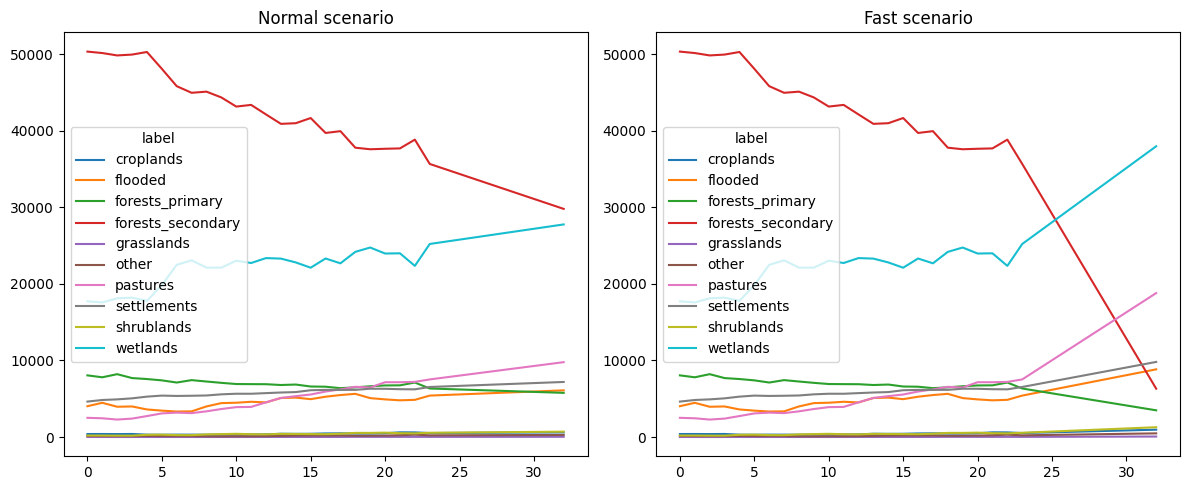

In [168]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
area_normal.set_index("label").T.plot(ax=ax[0])
area_fast.set_index("label").T.plot(ax=ax[1])

ax[0].set_title("Normal scenario")
ax[1].set_title("Fast scenario")

fig.tight_layout()

In [159]:
sequestration_columns = [
    "emission_co2e_co2_lndu_biomass_sequestration_grasslands",
    "emission_co2e_co2_lndu_biomass_sequestration_other",
    "emission_co2e_co2_lndu_biomass_sequestration_pastures",
    "emission_co2e_co2_lndu_biomass_sequestration_settlements",
    "emission_co2e_co2_lndu_biomass_sequestration_shrublands",
    "emission_co2e_co2_lndu_biomass_sequestration_wetlands",
    "emission_co2e_subsector_total_frst",
]

In [160]:
fast_sequestration = res_fast[sequestration_columns].sum(axis=1)
normal_sequestration = res_normal[sequestration_columns].sum(axis=1)

In [163]:
(res_normal - res_fast).abs().max().max()

np.float64(4.06545911602052e-07)

<Axes: xlabel='time_period'>

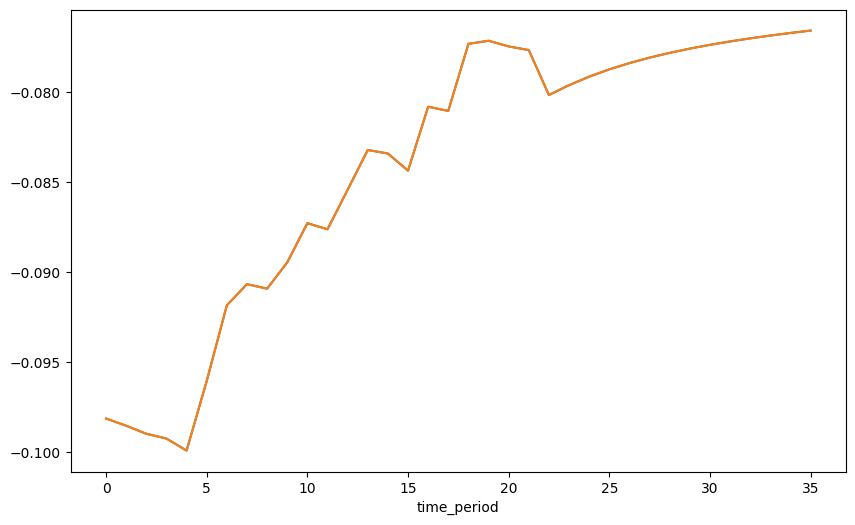

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
normal_sequestration.plot(ax=ax, label="Normal Sequestration")
fast_sequestration.plot(ax=ax, label="Fast Sequestration")

In [ ]:
fast